In [ ]:
from evoscape.jax.flax_models.landscape_flax import LandscapeFlax
from evoscape.jax.flax_models.autoencoder_flax import AutoEncoder

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape, visualize_landscape_t
from evoscape.jax.dynamics import state_probs
from evoscape.jax.config import DATA_DIR
from evoscape.jax.losses import mmd_traj

from sklearn.mixture import GaussianMixture

plt.style.use("default")


Here is the general way of training a JAX landscape :
- creating a Landscape() from evoscape
- converting it in a LandscapeFlax() : some parameters need to be added
- creating an autoencoder from this LandscapeFlax object
- loading the data
- training the autoencoder
- analyzing the model obtained

## Creating the evoscape Landscape

Landscape with modules:
Node: x=2.9; y=0.2; a=[0.5]; s=[1.]; tau=1.0,
Node: x=1.3999999; y=2.7980764; a=[0.5]; s=[1.]; tau=1.0,
Node: x=-1.6000003; y=2.7980762; a=[0.5]; s=[1.]; tau=1.0,
Node: x=-3.1; y=0.19999973; a=[0.5]; s=[1.]; tau=1.0,
Node: x=-1.5999998; y=-2.3980763; a=[0.5]; s=[1.]; tau=1.0,
Node: x=1.3999997; y=-2.3980763; a=[0.5]; s=[1.]; tau=1.0


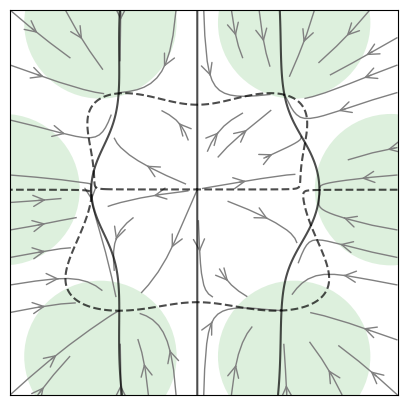

In [ ]:
# the offsets are here to center the modules around the initialization of the autoencoder.
# The training usually works way better that way

xx = [jnp.cos(2*jnp.pi*k/6)*3 + -0.1 for k in range(6)] 
yy = [jnp.sin(2*jnp.pi*k/6)*3 + 0.2 for k in range(6)]

modules = [Node(x=x, y=y, a=np.array([0.5]), s=np.array([1.0]), tau=1.) for x,y in zip(xx, yy)]

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    # morphogen_times=(50.,),
)

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')


## Converting it into a LandscapeFlax, creating the autoencoder

In [ ]:
# Initializing the LandscapeFlax
# rngs is an object in charge of giving random numbers whenever the landscape needs it
# usually all flax modules need to be initialized with an Rngs object
rngs = nnx.Rngs(0)
landscape_flax = LandscapeFlax(landscape, rngs)

# these are the parameter of the simulation
init_noise = 0.1
t0 = 0.
tf = 26.
nt = 10
ndt = 100
noise = 0.1

# In my opinion, we did a very poor job designing the regimes in landscapeFlax.
# Just so you know, if you ever have to dig into it, it’s really poorly implemented and would probably need to be rewritten.
# One example is that we have to use the `set_signal_params` function even though we’re using a constant regime.
# But if we don’t call this function, the landscape will have a problem with the regimes.
# However, for now, you don’t need to understand the logic behind it—you can just use them as is. 

landscape_flax.set_simulation(init_noise=init_noise, t0=t0, tf=tf, nt=nt, ndt=ndt, noise=noise)
landscape_flax.set_regime_params(signal_param=None)
landscape_flax.set_state_probs(state_probs)

# Initialiazing the autoencoder
dims_encoder = [4, 8, 4, 2]
dims_decoder = [2, 64, 32, 4]

autoencoder = AutoEncoder(landscape_flax, dims_decoder=dims_decoder, dims_encoder=dims_encoder, rngs=rngs)

## Loading the data

In [ ]:
filepath = DATA_DIR / "synthetic_data" / "synthetic_data_2.npy"

target_traj = np.load(filepath)

# there are too many cells, I only choose 200 of them randomly
# this is a quick fix. In practice we probably should construct random batches of cells
# and then use a DataLoader in the training loop
# The JAX ecosystem doesn't have dataloaders, but I think there is a tutorial that uses Tensoflow datasets
indices = np.random.choice(target_traj.shape[1], size=200, replace=False)
target_traj = target_traj[:, indices, ::100]

print(target_traj.shape)

(4, 200, 10)


As we can see, the target_traj has a shape (cell_data, number_of_cells, number_of_timepoint).
This is the general convention we use to store the trajectories. This generally doesn't match up with the convention of the nnx.Module that are vectorized for batches of the form (number_of_cell, cell_data). But most of the transposition and conversions are done inside LandscapeFlax, so no need to worry about it.
And it's honestly not that big of a problem.

Generally, I think it's useful to print the shapes of the trajectories because it can become a little confusing.

Below is an example of how to compute trajectories, and error on these trajectories.

In [5]:
q_init = target_traj[:, :, 0]
print(q_init.shape)

simulated_traj = autoencoder(q_init)
print(simulated_traj.shape)

loss = mmd_traj(simulated_traj, target_traj)
print(loss)

(4, 200)
(4, 200, 10)
9.022634


N.B : In the case of the synthetic data, we have access to the trajectories. So we could simply use an L2 loss on the trajectories. But in the general case, we don't have access to the trajectories, only cloud of points, and thus we need to use the MMD (which is probably less effective).
So we tried to fit the synthetic data with the MMD because it's a little bit more difficult than with the L2.

But when we can, we do use the L2 loss, and that's what we do for the Drosophila.

(4, 200)
(2, 200)


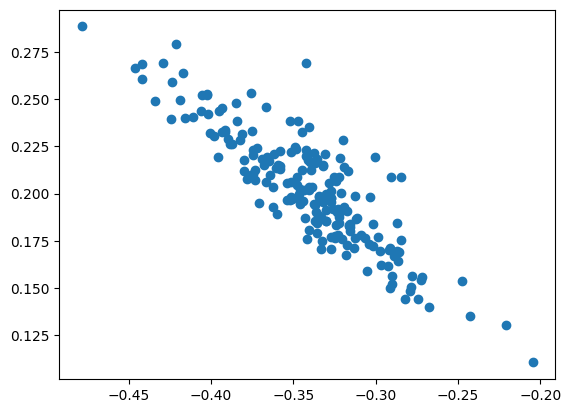

In [ ]:
print(q_init.shape)
# this is a case where we need to transpose before being able to use the vectorization of the encoder
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

I also like to plot where the initialized encoder send the cells. Is it really spread out ? What shape does it have ?

## Training the model

Époque 0 | Loss: 10.4812
Époque 50 | Loss: 1.5019
Époque 100 | Loss: 0.8960
Époque 150 | Loss: 0.6134
Époque 200 | Loss: 0.6719
Époque 250 | Loss: 0.5461
Époque 300 | Loss: 0.4044
Époque 350 | Loss: 0.2747
Époque 400 | Loss: 0.1826
Époque 450 | Loss: 0.2134
Époque 500 | Loss: 0.1469
Époque 550 | Loss: 0.1758
Époque 600 | Loss: 0.1980
Époque 650 | Loss: 0.1604
Époque 700 | Loss: 0.1327
Époque 750 | Loss: 0.1734


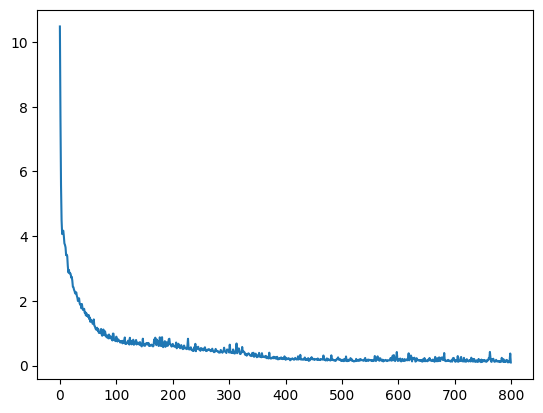

In [ ]:
# Defining the optimizer 
# You first define an optax optimizer, then you wrap it with nnx.Optimizer

# adamw seems to work pretty well, but we did not test that many other optimizers.
# maybe it would be really interesting to use a different optimizer for the landscape and the encoder/decoder,
# because these two spaces of parameters must be really different (i.e. maybe training is better when you
# take big steps for the encoder/decoder and small steps for the landscape or vice-versa).

tx = optax.adamw(
    learning_rate = 5e-3,
    weight_decay = 5e-4,
)

optimizer = nnx.Optimizer(autoencoder, tx, wrt=nnx.Param)

# Defining the loss function, and the train_step 

def loss_fn(autoencoder, target_traj):
    # Forward pass
    q_init = target_traj[:,:,0]
    simulated_traj = autoencoder(q_init)

    # Loss on cloud points
    loss_dynamics = mmd_traj(simulated_traj, target_traj)

    # Loss on encoding the trajectory
    encoded_decoded_traj = autoencoder.forward_no_dynamics(target_traj)
    loss_encoding = jnp.mean((encoded_decoded_traj - target_traj)**2)

    # After studying it, loss_encoding should maybe be only on the initial condition rather than on
    # the whole trajectory... I let it that way for now, but maybe we should change this
    
    return loss_dynamics + loss_encoding

# with flax, you use nnx.jit rather than jax.jit
# nnx.jit is adapted to nnx.Modules and object oriented
@nnx.jit
def train_step(autoencoder, optimizer: nnx.Optimizer, target_traj):
    # nnx.value_and_grad computes the gradient with respect to the nnx.Params
    loss, grads = nnx.value_and_grad(loss_fn)(autoencoder, target_traj)
    
    optimizer.update(autoencoder, grads)
    
    return loss

# Training loop 
n_epochs = 800
loss_vals = []

for epoch in range(n_epochs):
    loss_val = train_step(autoencoder, optimizer, target_traj)
    
    if epoch%50 == 0:
        print(f"Epoch {epoch} | Loss: {loss_val:.4f}")

    loss_vals.append(loss_val)

plt.plot(loss_vals)

Plotting the resulting landscape

Landscape with modules:
Node: x=3.0445072650909424; y=0.5751855969429016; a=[0.44871843]; s=[0.8426574]; tau=1.0,
Node: x=1.1841248273849487; y=2.589439868927002; a=[0.6162932]; s=[1.1833768]; tau=1.0,
Node: x=-1.6625505685806274; y=2.670931100845337; a=[0.5886836]; s=[1.1359953]; tau=1.0,
Node: x=-3.06119966506958; y=0.26155930757522583; a=[0.43988794]; s=[1.0974586]; tau=1.0,
Node: x=-1.4415295124053955; y=-2.1557459831237793; a=[0.80710286]; s=[1.1460074]; tau=1.0,
Node: x=1.544305682182312; y=-2.5938174724578857; a=[0.38458797]; s=[0.7850419]; tau=1.0


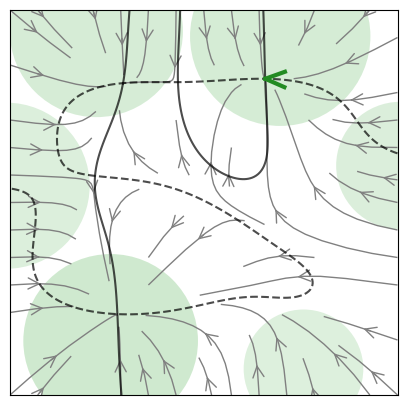

In [8]:
landscape = autoencoder.landscape_flax.get_landscape()

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 20., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)

## Analyzing the model

(4, 200)
(2, 200)


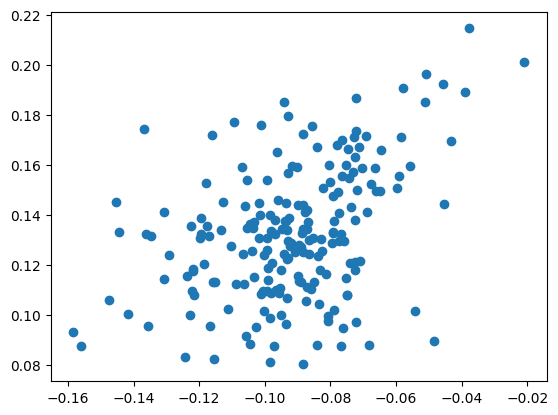

In [9]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

Again, we can plot the initial condition to see how much the encoder changed during training.

(2, 200, 10)


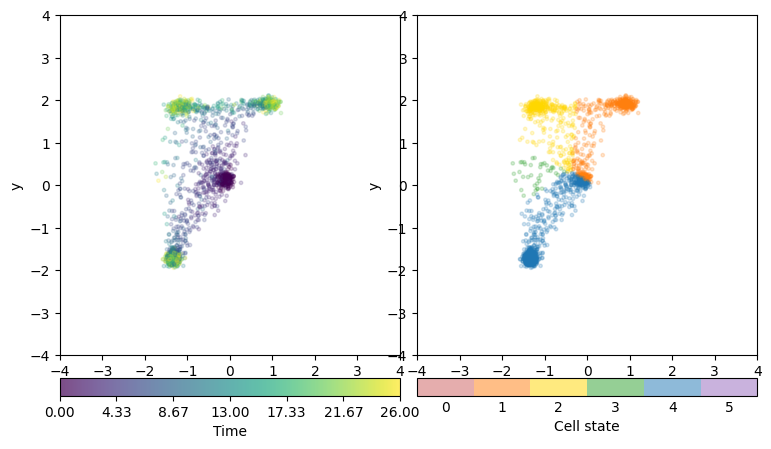

In [10]:
traj, states = autoencoder.landscape_flax(q_init_latent)

print(traj.shape)

fig = plot_traj(traj, states, t0, tf, nt, L=4)

Above is the simulated trajectory, below is the real trajectory (in the latent space) : they are not the same at all !!
This is why the encoding loss we use right now is not satisfactory.

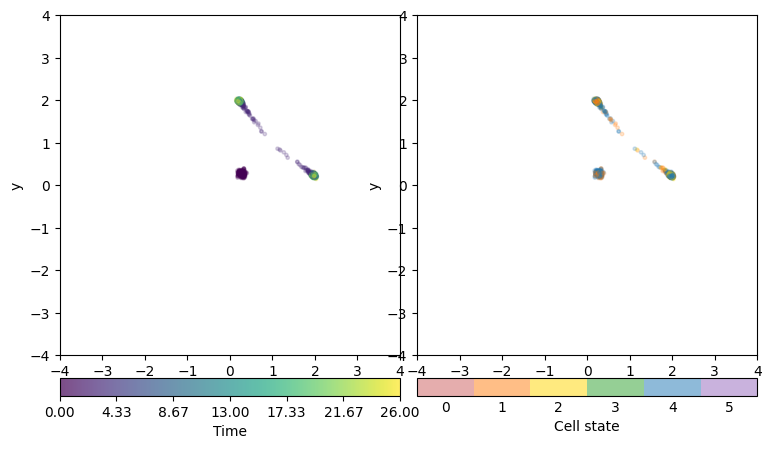

In [11]:
fig = plot_traj(target_traj, states, t0, tf, nt, L=4)

These points are the centers of the stable positions in the real space.
It's useful to see where they end up through the encoder, or how to attain them from the decoder.

In [12]:
q_centroids = jnp.array([[0.24, 1.96, 0.43, 0.43],
                        [1.96, 0.24, 0.09, 3.93],
                        [1.97, 0.23, 3.93, 0.09]])

q_latent = autoencoder.encoder(q_centroids)

print(q_latent)

[[-0.96080506  0.13542092]
 [ 1.0638078   2.179874  ]
 [-1.302486    1.8366398 ]]


[1.97 0.23 3.93 0.09]
[-1.302486   1.8366398]


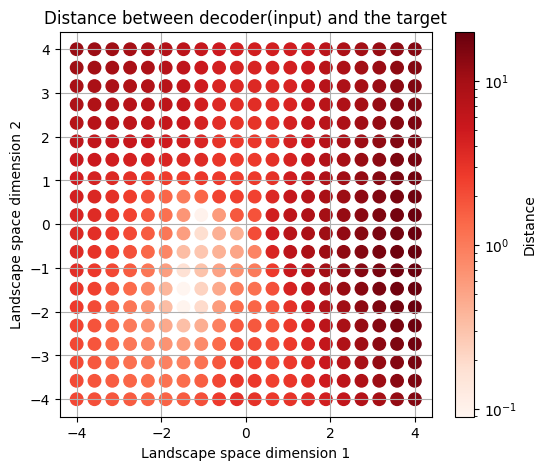

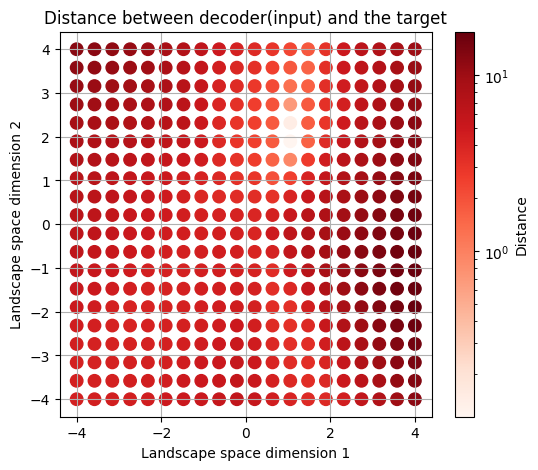

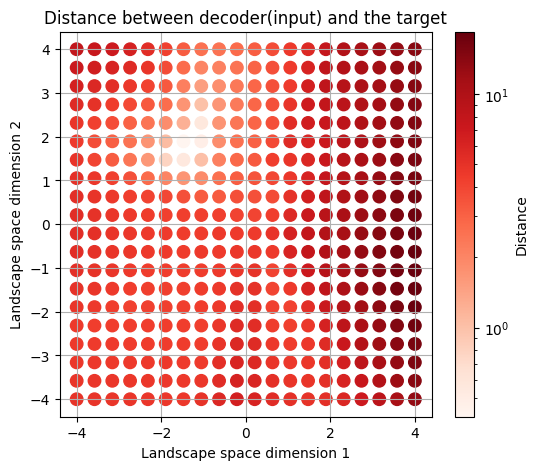

In [13]:
from matplotlib.colors import LogNorm

def plot_decoder_grid_search(decoder, target, n_points=10):
    """
    Parameters
    ----------
    decoder : nnx.Module
        Décodeur 2D -> 4D.
    target : array-like, shape (4,)
        Point cible dans l'espace de sortie.
    n_points : int
        Nombre de points par axe.
    """

    # Construction de la grille
    x = jnp.linspace(-4.0, 4.0, n_points)
    y = jnp.linspace(-4.0, 4.0, n_points)

    X, Y = jnp.meshgrid(x, y)

    # (n_points**2, 2)
    inputs = jnp.stack([X.ravel(), Y.ravel()], axis=1)

    # Passage dans le décodeur
    outputs = decoder(inputs)          # (N, 4)

    # Distances euclidiennes
    target = jnp.asarray(target)
    distances = jnp.linalg.norm(outputs - target, axis=1)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(
        np.array(inputs[:, 0]),
        np.array(inputs[:, 1]),
        c=np.array(distances),
        cmap="Reds",
        norm=LogNorm(),
        s=80,
    )

    plt.xlabel("Landscape space dimension 1")
    plt.ylabel("Landscape space dimension 2")
    plt.title("Distance between decoder(input) and the target")
    plt.colorbar(label="Distance")
    plt.grid(True)
    plt.show()

idx = 2
target = q_centroids[idx]
target_latent = q_latent[idx]
print(target)
print(target_latent)

for idx in [0,1,2]:
    plot_decoder_grid_search(
        decoder=autoencoder.decoder,
        target=q_centroids[idx],
        n_points=20,
    )

Landscape with modules:
Node: x=3.0445072650909424; y=0.5751855969429016; a=[0.44871843]; s=[0.8426574]; tau=1.0,
Node: x=1.1841248273849487; y=2.589439868927002; a=[0.6162932]; s=[1.1833768]; tau=1.0,
Node: x=-1.6625505685806274; y=2.670931100845337; a=[0.5886836]; s=[1.1359953]; tau=1.0,
Node: x=-3.06119966506958; y=0.26155930757522583; a=[0.43988794]; s=[1.0974586]; tau=1.0,
Node: x=-1.4415295124053955; y=-2.1557459831237793; a=[0.80710286]; s=[1.1460074]; tau=1.0,
Node: x=1.544305682182312; y=-2.5938174724578857; a=[0.38458797]; s=[0.7850419]; tau=1.0


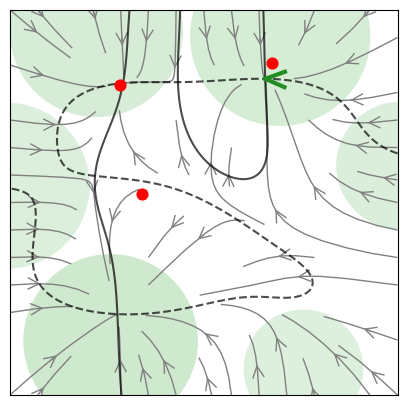

In [14]:
landscape = autoencoder.landscape_flax.get_landscape()

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(
    landscape, xx, yy, 20., color_scheme='fp_types',
    traj_times=(0., 20., 201), traj_init_cond=(2.,2.),
    traj_start=100, q_centroids=q_latent
)

## GMM and trajectories

Lastly, we can plot the simulated trajectories of the particles in the real space to see if they match with the real ones.

In [15]:
estimated_traj = autoencoder(q_init)

In [ ]:
n_clusters = 3

# ============================================================
# Fit du GMM sur les positions finales target
# ============================================================

target_final = target_traj[:, :, -1].T      # (N, 4)
estimated_final = estimated_traj[:, :, -1].T

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type="full",
    random_state=42
)

gmm.fit(target_final)

# ============================================================
# Attribution des clusters
# ============================================================

target_labels = gmm.predict(target_final)
estimated_labels = gmm.predict(estimated_final)

# ============================================================
# Réordonnancement (optionnel)
# ============================================================

order = np.argsort(gmm.means_[:, 0])

target_labels_ordered = np.zeros_like(target_labels)
estimated_labels_ordered = np.zeros_like(estimated_labels)

for new_label, old_label in enumerate(order):
    target_labels_ordered[target_labels == old_label] = new_label
    estimated_labels_ordered[estimated_labels == old_label] = new_label

target_labels = target_labels_ordered
estimated_labels = estimated_labels_ordered

# ============================================================
# Construction des clusters
# ============================================================

target_clusters = []
estimated_clusters = []

for k in range(n_clusters):

    target_mask = target_labels == k
    estimated_mask = estimated_labels == k

    target_clusters.append(
        target_traj[:, target_mask, :]
    )

    estimated_clusters.append(
        estimated_traj[:, estimated_mask, :]
    )

    print(
        f"Cluster {k}: "
        f"target={target_mask.sum()} "
        f"estimated={estimated_mask.sum()}"
    )

Cluster 0: target=106 estimated=114
Cluster 1: target=42 estimated=43
Cluster 2: target=52 estimated=43


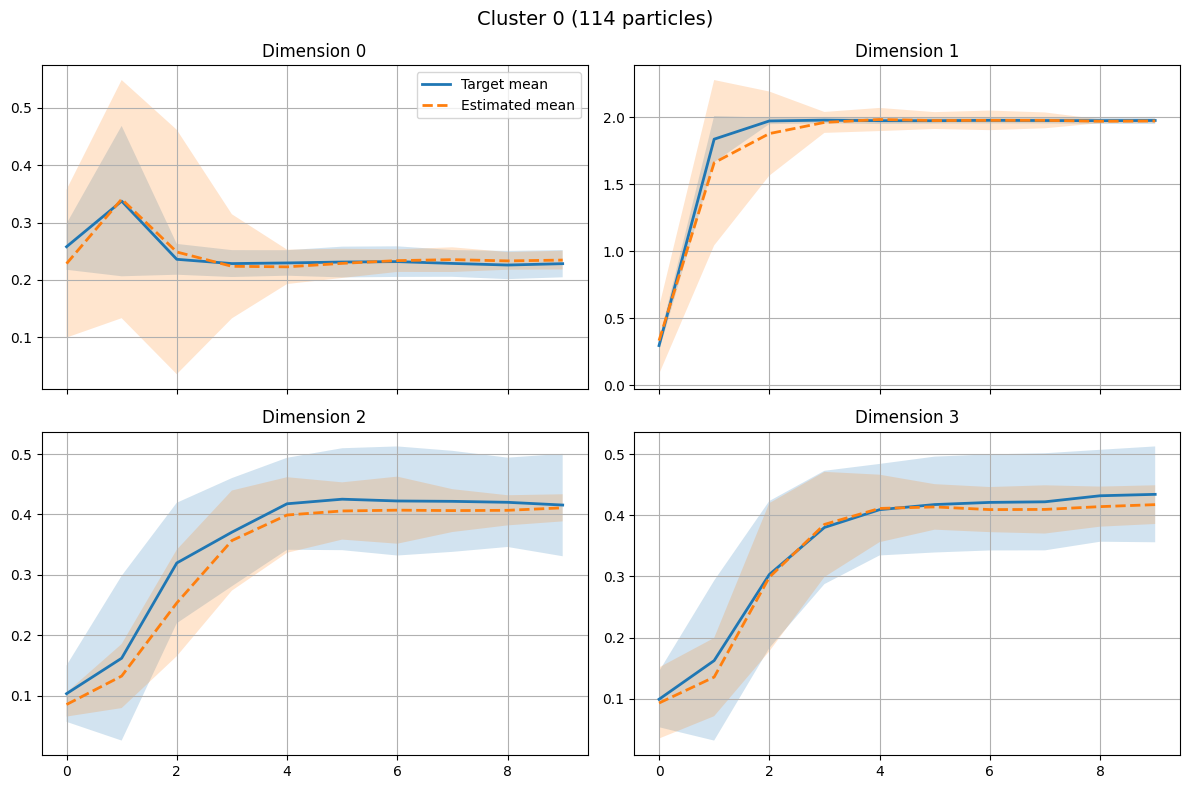

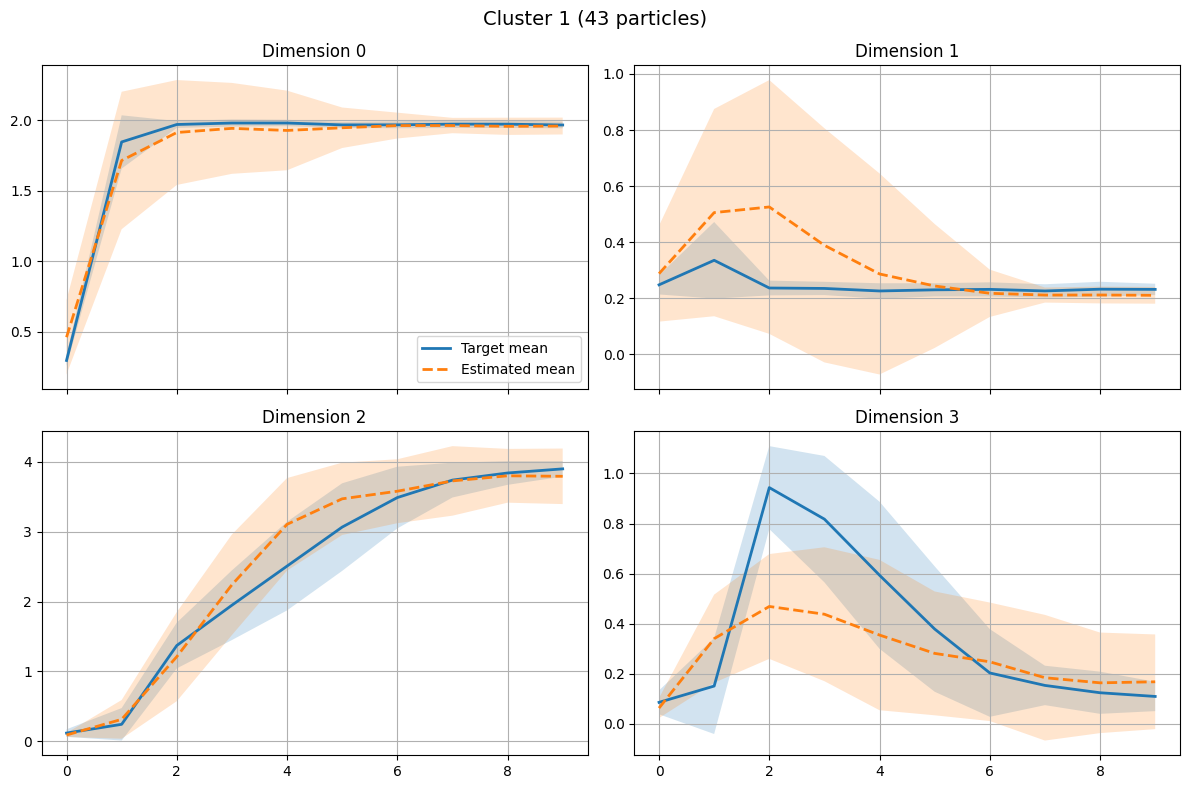

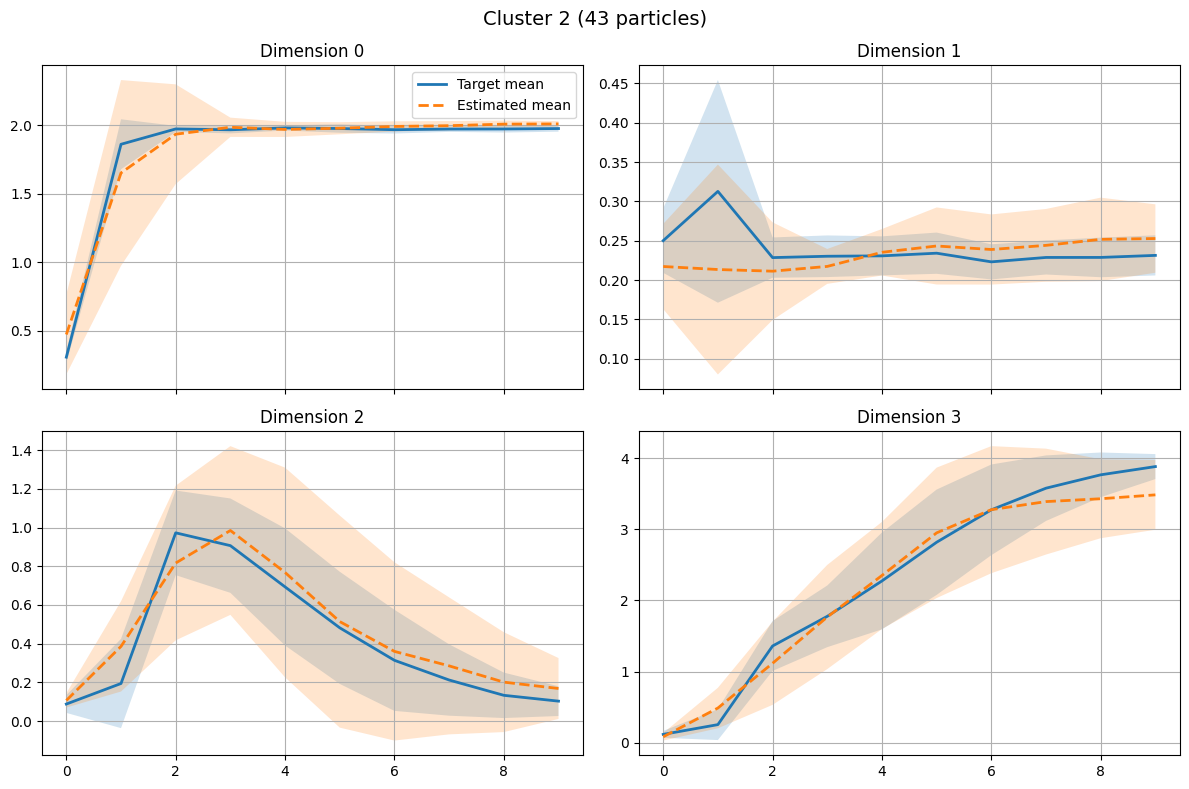

In [17]:
# ============================================================================
# Plot 2x2 par cluster : mean ± std pour target et estimated
# ============================================================================

timepoints = np.arange(target_traj.shape[2])
n_clusters = len(target_clusters)

for cluster_id in range(n_clusters):

    est = estimated_clusters[cluster_id]  # (4, Nk, T)
    tar = target_clusters[cluster_id]     # (4, Nk, T)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    fig.suptitle(f"Cluster {cluster_id} ({est.shape[1]} particles)", fontsize=14)

    for dim in range(4):

        ax = axes[dim]

        # -------------------------
        # Moyennes
        # -------------------------
        est_mean = np.mean(est[dim], axis=0)
        tar_mean = np.mean(tar[dim], axis=0)

        # -------------------------
        # Std
        # -------------------------
        est_std = np.std(est[dim], axis=0)
        tar_std = np.std(tar[dim], axis=0)

        # -------------------------
        # Target
        # -------------------------
        ax.plot(timepoints, tar_mean, label="Target mean", linewidth=2)
        ax.fill_between(
            timepoints,
            tar_mean - tar_std,
            tar_mean + tar_std,
            alpha=0.2
        )

        # -------------------------
        # Estimated
        # -------------------------
        ax.plot(timepoints, est_mean, "--", label="Estimated mean", linewidth=2)
        ax.fill_between(
            timepoints,
            est_mean - est_std,
            est_mean + est_std,
            alpha=0.2
        )

        ax.set_title(f"Dimension {dim}")
        ax.grid(True)

        if dim == 0:
            ax.legend()

    # Si jamais un subplot reste vide (ici non mais sécurité)
    for i in range(4, 4):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()